In [1]:
from generator import GenLOwInt, GenLOwIntOpt
from ParametersDefault import Parameters
from qipmdev import qipmadaptive

import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import time

np.set_printoptions(edgeitems=30, linewidth=100000)

# Size 8

In [2]:
m, n = 8, 1000000
parameters = Parameters()
(A, Bidx, b, c, opt_x, opt_y, opt_s, int_x, int_y, int_s) = GenLOwIntOpt(m-1,n-1,m,n-m-1,parameters)
print('Condition Number of Ahat:                 ', format(np.linalg.cond(np.linalg.solve(A[:,Bidx], A)), ".2E"))
print('Initial Solution Complementarity Gap:     ', format(np.dot(int_x,int_s), ".2E"))
print('Initial Solution Primal Feasibility Error:', format(np.linalg.norm(A@int_x-b), ".2E"))
print('Initial Solution Dual Feasibility Error:  ', format(np.linalg.norm((A.T@int_y)+int_s-c), ".2E"))

print('Optimal Solution Complementarity Gap:     ', format(np.dot(opt_x,opt_s), ".2E"))
print('Optimal Solution Primal Feasibility Error:', format(np.linalg.norm(A@opt_x-b), ".2E"))
print('Optimal Solution Dual Feasibility Error:  ', format(np.linalg.norm((A.T@opt_y)+opt_s-c), ".2E"))
mu = np.dot(int_x.T, int_s) / n
print('Initial Proximity:                        ', format(np.linalg.norm((int_x*int_s)/mu - np.ones(n)), ".2E"))

Basis:                                     [0, 1, 2, 3, 4, 5, 6, 7]
Condition number of A:                     3.04E+00
Condition number of A_B:                   1.00E+00
Condition Number of Ahat:                  3.10E+00
Initial Solution Complementarity Gap:      1.00E+06
Initial Solution Primal Feasibility Error: 1.81E-14
Initial Solution Dual Feasibility Error:   4.31E-14
Optimal Solution Complementarity Gap:      0.00E+00
Optimal Solution Primal Feasibility Error: 0.00E+00
Optimal Solution Dual Feasibility Error:   0.00E+00
Initial Proximity:                         0.00E+00


In [3]:
start = time.time()
x,s,y,cond,resadp,pfeas,dfeas,Qcalls,TimeInfo = qipmadaptive(A, Bidx, b, c, 
                                                  int_x, int_y, int_s, 
                                                  n, m, 
                                                  neighborhood = 'Small',
                                                  beta=0.9,           # initial reduction parameter
                                                  gamma= 0.5,         # neighborhood parameter
                                                  ir_precision=1e-2,  # IR precision
                                                  precision=10,       # IPM desired complementarity gap
                                                  use_simulator=False) # Use local simulator instead of IBM hardware
end = time.time()
runtime = end-start

Initial Proximity:0.00E+00, with bound of 5.00E-01
### Iteration 1 ###
mu: 1.00E+00
System Built in 0.0201 seconds with beta:0.9.
Cond(Mhat): 9.60E+00
Using IBM backend: ibm_fez
QC Built and System Solved in 133.8756 seconds.
Refiner terminated within 11 iterations, at error 3.24E-02.
LS terminated with alpha = 1.00E+00 in 0.0027 seconds.
### Iteration 2 ###
mu: 9.00E-01
System Built in 0.0268 seconds with beta:0.1.
Cond(Mhat): 7.96E+00
Using IBM backend: ibm_fez
QC Built and System Solved in 131.7189 seconds.
Refiner terminated within 10 iterations, at error 9.03E-03.
LS terminated with alpha = 1.00E+00 in 0.0026 seconds.
### Iteration 3 ###
mu: 9.00E-02
System Built in 0.0241 seconds with beta:0.1.
Cond(Mhat): 1.07E+00
Using IBM backend: ibm_fez
QC Built and System Solved in 70.5642 seconds.
Refiner terminated within 6 iterations, at error 6.55E-03.
LS terminated with alpha = 1.00E+00 in 0.0031 seconds.
### Iteration 4 ###
mu: 9.00E-03
System Built in 0.0230 seconds with beta:0.1.
Co

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(name="QLSAs")

service.backends()


[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_torino')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_kingston')>]

In [5]:
runtime

609.4259769916534

In [6]:
np.linalg.norm(x-opt_x)

0.008999960489255132

In [7]:
np.linalg.norm(y-opt_y)

1.3242492150596568e-05

In [8]:
np.linalg.norm(s-opt_s)

2.4848463318532567e-05

In [9]:
print('Solution Complementarity Gap:                  ', format(np.dot(x,s), ".2E"))
print('Solution Primal Feasibility Error:             ', format(np.linalg.norm(A@x-b), ".2E"))
print('Solution Dual Feasibility Error:               ', format(np.linalg.norm((A.T@y)+s-c), ".2E"))

Solution Complementarity Gap:                   9.00E+00
Solution Primal Feasibility Error:              9.87E-12
Solution Dual Feasibility Error:                1.41E-13


In [10]:
print('Total Number of Quantum Calls:                 ', Qcalls)
print('Total Time Spent is System Building:           ', TimeInfo['SB'])
print('Total Time Spent is Circuit Building and Solve:', TimeInfo['SB'])
print('Total Time Spent in Line Search:               ', TimeInfo['LS'])

Total Number of Quantum Calls:                  41
Total Time Spent is System Building:            0.14171695709228516
Total Time Spent is Circuit Building and Solve: 0.14171695709228516
Total Time Spent in Line Search:                0.01637721061706543


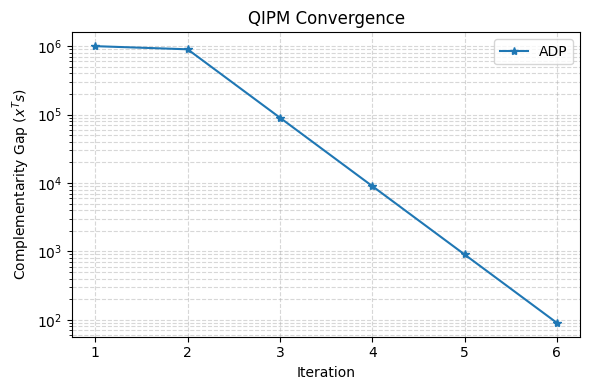

In [11]:
resadp = np.asarray(resadp, dtype=float)
itersadp = np.arange(1, len(resadp) + 1)

plt.figure(figsize=(6,4))
plt.semilogy(itersadp, n*resadp, marker='*', label='ADP') 
plt.xlabel('Iteration')
plt.ylabel(r'Complementarity Gap ($x^T s$)')
plt.title('QIPM Convergence')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()

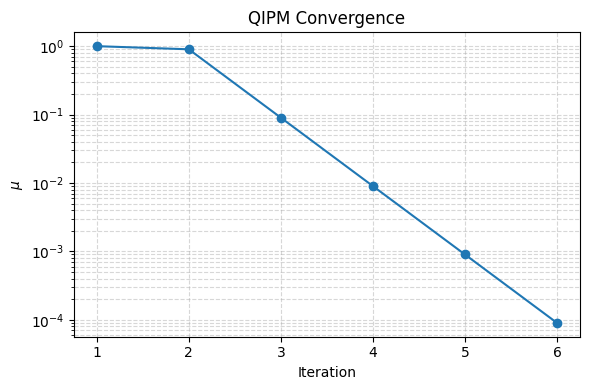

In [12]:
res = np.asarray(resadp, dtype=float)
iters = np.arange(1, len(res) + 1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, res, marker='o')
plt.xlabel('Iteration')
plt.ylabel(r'$\mu$')
plt.title('QIPM Convergence')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

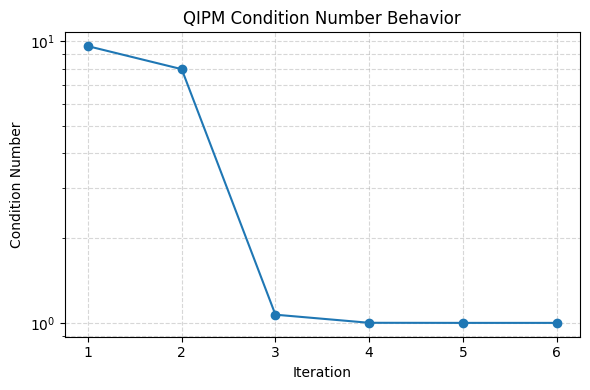

In [13]:
cond = np.asarray(cond, dtype=float)
iters = np.arange(1, len(cond)+1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, cond, marker='o') 
plt.xlabel('Iteration')
plt.ylabel('Condition Number')
plt.title('QIPM Condition Number Behavior')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

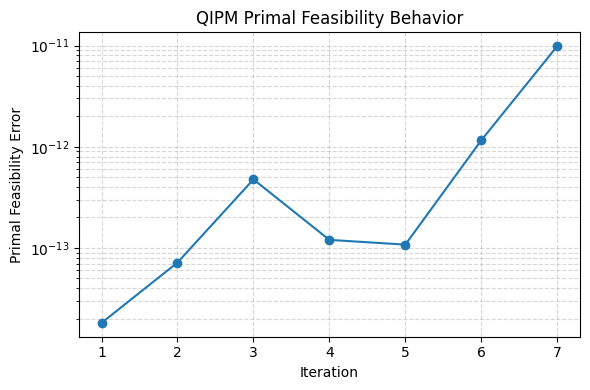

In [14]:
pfeas = np.asarray(pfeas, dtype=float)
iters = np.arange(1, len(pfeas)+1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, pfeas, marker='o') 
plt.xlabel('Iteration')
plt.ylabel('Primal Feasibility Error')
plt.title('QIPM Primal Feasibility Behavior')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

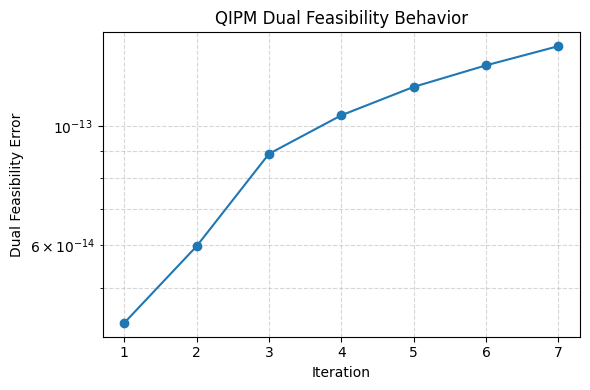

In [15]:
dfeas = np.asarray(dfeas, dtype=float)
iters = np.arange(1, len(dfeas) + 1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, dfeas, marker='o') 
plt.xlabel('Iteration')
plt.ylabel('Dual Feasibility Error')
plt.title('QIPM Dual Feasibility Behavior')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Size 32

In [16]:
m, n = 32, 1000000
parameters = Parameters()
(A, Bidx, b, c, opt_x, opt_y, opt_s, int_x, int_y, int_s) = GenLOwIntOpt(m-1,n-1,m,n-m-1,parameters)
print('Condition Number of Ahat:                 ', format(np.linalg.cond(np.linalg.solve(A[:,Bidx], A)), ".2E"))
print('Initial Solution Complementarity Gap:     ', format(np.dot(int_x,int_s), ".2E"))
print('Initial Solution Primal Feasibility Error:', format(np.linalg.norm(A@int_x-b), ".2E"))
print('Initial Solution Dual Feasibility Error:  ', format(np.linalg.norm((A.T@int_y)+int_s-c), ".2E"))

print('Optimal Solution Complementarity Gap:     ', format(np.dot(opt_x,opt_s), ".2E"))
print('Optimal Solution Primal Feasibility Error:', format(np.linalg.norm(A@opt_x-b), ".2E"))
print('Optimal Solution Dual Feasibility Error:  ', format(np.linalg.norm((A.T@opt_y)+opt_s-c), ".2E"))
mu = np.dot(int_x.T, int_s) / n
print('Initial Proximity:                        ', format(np.linalg.norm((int_x*int_s)/mu - np.ones(n)), ".2E"))

Basis:                                     [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Condition number of A:                     1.09E+01
Condition number of A_B:                   1.00E+00
Condition Number of Ahat:                  1.45E+01
Initial Solution Complementarity Gap:      1.00E+06
Initial Solution Primal Feasibility Error: 1.58E-14
Initial Solution Dual Feasibility Error:   6.75E-14
Optimal Solution Complementarity Gap:      0.00E+00
Optimal Solution Primal Feasibility Error: 0.00E+00
Optimal Solution Dual Feasibility Error:   0.00E+00
Initial Proximity:                         0.00E+00


In [29]:
start = time.time()
x,s,y,cond,resadp,pfeas,dfeas,Qcalls,TimeInfo = qipmadaptive(A, Bidx, b, c, 
                                                  int_x, int_y, int_s, 
                                                  n, m, 
                                                  neighborhood = 'Small',
                                                  beta=0.9, 
                                                  gamma= 0.5, # neighborhood parameter
                                                  ir_precision=1e-2, 
                                                  precision=1e-4,
                                                  use_simulator=False) # Use local simulator
end = time.time()
runtime = end-start

Initial Proximity:0.00E+00, with bound of 5.00E-01
### Iteration 1 ###
mu: 1.00E+00
System Built in 0.0603 seconds with beta:0.9.
Cond(Mhat): 2.10E+02
Using IBM backend: ibm_fez
QC Built and System Solved in 809.1192 seconds.
Refiner terminated within 11 iterations, at error 9.58E-01.
LS terminated with alpha = 5.00E-01 in 0.0065 seconds.
### Iteration 2 ###
mu: 9.50E-01
System Built in 0.0726 seconds with beta:0.1.
Cond(Mhat): 1.90E+02
Using IBM backend: ibm_fez


/Users/mhms379/Downloads/QLSA/QLSAs/.venv/lib/python3.13/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1210: UserWarning: This instance has met its usage limit. Workloads will not run until time is made available. Check https://quantum.cloud.ibm.com/instances/crn%3Av1%3Abluemix%3Apublic%3Aquantum-computing%3Aus-east%3Aa%2F4faec53aed024d28bde9a69e591373b8%3A6d3f26ab-c13a-4044-b057-3d43083fa5de%3A%3A for more details.
  warnings.warn(


RequestsApiError: 'HTTPSConnectionPool(host=\'quantum.cloud.ibm.com\', port=443): Max retries exceeded with url: /api/v1/jobs/d6tl7ik69uic73chadfg?exclude_params=true (Caused by NameResolutionError("HTTPSConnection(host=\'quantum.cloud.ibm.com\', port=443): Failed to resolve \'quantum.cloud.ibm.com\' ([Errno 8] nodename nor servname provided, or not known)"))'

In [ ]:
runtime

202.4230179786682

In [ ]:
np.linalg.norm(x-opt_x)

8.999864469366731e-08

In [ ]:
np.linalg.norm(y-opt_y)

2.6317497872850163e-10

In [ ]:
np.linalg.norm(s-opt_s)

5.214998094240362e-10

In [ ]:
print('Solution Complementarity Gap:                  ', format(np.dot(x,s), ".2E"))
print('Solution Primal Feasibility Error:             ', format(np.linalg.norm(A@x-b), ".2E"))
print('Solution Dual Feasibility Error:               ', format(np.linalg.norm((A.T@y)+s-c), ".2E"))

Solution Complementarity Gap:                   9.00E-05
Solution Primal Feasibility Error:              1.51E-14
Solution Dual Feasibility Error:                1.88E-13


In [ ]:
print('Total Number of Quantum Calls:                 ', Qcalls)
print('Total Time Spent is System Building:           ', TimeInfo['SB'])
print('Total Time Spent is Circuit Building and Solve:', TimeInfo['SB'])
print('Total Time Spent in Line Search:               ', TimeInfo['LS'])

Total Number of Quantum Calls:                  36
Total Time Spent is System Building:            0.8739669322967529
Total Time Spent is Circuit Building and Solve: 0.8739669322967529
Total Time Spent in Line Search:                0.027814626693725586


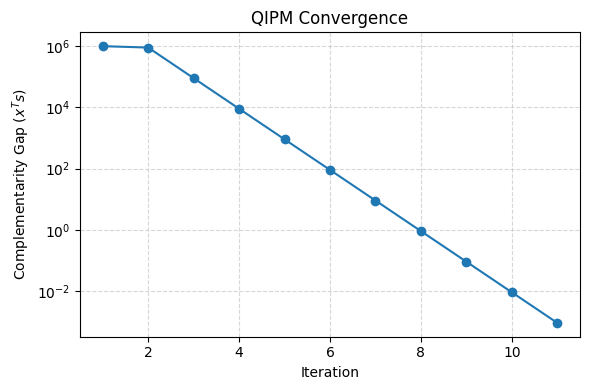

In [ ]:
resadp = np.asarray(resadp, dtype=float)
iters = np.arange(1, len(resadp) + 1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, n*resadp, marker='o')
plt.xlabel('Iteration')
plt.ylabel(r'Complementarity Gap ($x^T s$)')
plt.title('QIPM Convergence')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

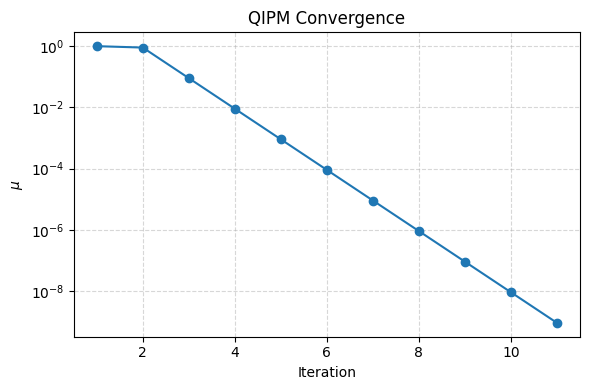

In [ ]:
res = np.asarray(resadp, dtype=float)
iters = np.arange(1, len(resadp) + 1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, res, marker='o')  # log scale is standard for IPM
plt.xlabel('Iteration')
plt.ylabel(r'$\mu$')
plt.title('QIPM Convergence')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

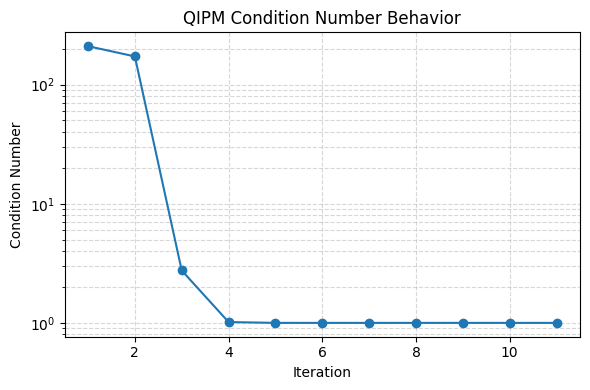

In [ ]:
cond = np.asarray(cond, dtype=float)
iters = np.arange(1, len(cond)+1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, cond, marker='o') 
plt.xlabel('Iteration')
plt.ylabel('Condition Number')
plt.title('QIPM Condition Number Behavior')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

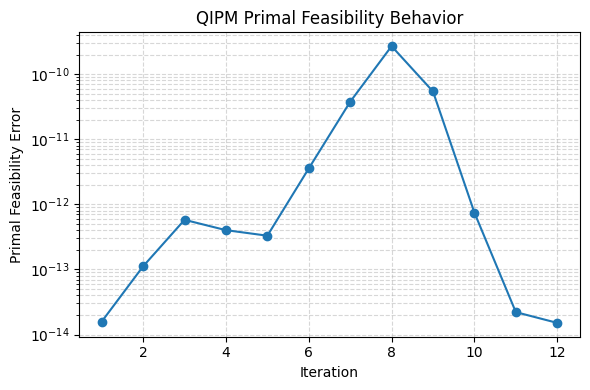

In [ ]:
pfeas = np.asarray(pfeas, dtype=float)
iters = np.arange(1, len(pfeas)+1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, pfeas, marker='o') 
plt.xlabel('Iteration')
plt.ylabel('Primal Feasibility Error')
plt.title('QIPM Primal Feasibility Behavior')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

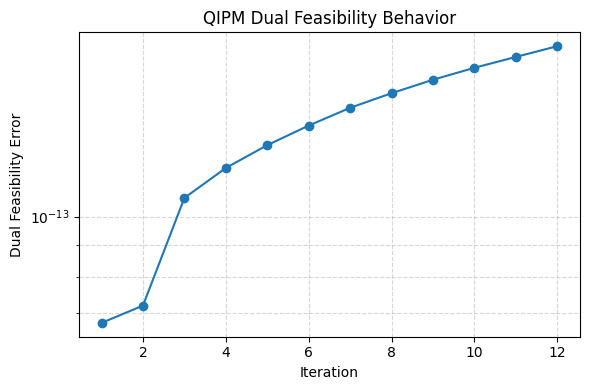

In [ ]:
dfeas = np.asarray(dfeas, dtype=float)
iters = np.arange(1, len(dfeas) + 1)

plt.figure(figsize=(6,4))
plt.semilogy(iters, dfeas, marker='o') 
plt.xlabel('Iteration')
plt.ylabel('Dual Feasibility Error')
plt.title('QIPM Dual Feasibility Behavior')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()